In [ ]:
# ================================
# 🔹 Download Kaggle Dataset (Colab)
# ================================
import kagglehub
import os

# Download dataset
DATASET_PATH = kagglehub.dataset_download(
    "aryashah2k/indian-medicinal-leaves-dataset"
)

print("Dataset downloaded to:", DATASET_PATH)

# -------------------------------
# 🔹 Find correct ImageFolder path
# -------------------------------
def find_class_folder(base_path):
    # If base path already contains class folders
    items = os.listdir(base_path)
    if all(os.path.isdir(os.path.join(base_path, i)) for i in items):
        return base_path

    # Otherwise, search one level deeper
    for item in items:
        sub_path = os.path.join(base_path, item)
        if os.path.isdir(sub_path):
            sub_items = os.listdir(sub_path)
            if all(os.path.isdir(os.path.join(sub_path, i)) for i in sub_items):
                return sub_path

    raise FileNotFoundError("❌ Could not find class folders for ImageFolder")

dataset_dir = find_class_folder(DATASET_PATH)

print("Final dataset directory:", dataset_dir)
print("Classes found:", os.listdir(dataset_dir))


Download already complete (9663451492 bytes).
Extracting files...
Dataset downloaded to: /root/.cache/kagglehub/datasets/aryashah2k/indian-medicinal-leaves-dataset/versions/1
Final dataset directory: /root/.cache/kagglehub/datasets/aryashah2k/indian-medicinal-leaves-dataset/versions/1
Classes found: ['Indian Medicinal Leaves Image Datasets']


In [ ]:
dataset_dir = os.path.join(
    DATASET_PATH,
    "Indian Medicinal Leaves Image Datasets"
)


In [ ]:
print(os.listdir(dataset_dir))


['Medicinal Leaf dataset', 'Medicinal plant dataset']


In [ ]:
dataset_dir = os.path.join(dataset_dir, "Medicinal plant dataset")


In [ ]:
print(os.listdir(dataset_dir))

['Pomegranate', 'Mint', 'Ganike', 'Doddapatre', 'Wood_sorel', 'Henna', 'Ashoka', 'Insulin', 'Gauva', 'Aloevera', 'Rose', 'Nithyapushpa', 'Pepper', 'Amruta_Balli', 'Arali', 'Neem', 'Jasmine', 'Raktachandini', 'Hibiscus', 'Basale', 'Nagadali', 'Lemon_grass', 'Geranium', 'Ekka', 'Bamboo', 'Curry_Leaf', 'Nooni', 'Honge', 'Amla', 'Ashwagandha', 'Avacado', 'Pappaya', 'Sapota', 'Brahmi', 'Betel_Nut', 'Tulasi', 'Mango', 'Castor', 'Lemon', 'Betel']


In [ ]:
# =====================================================
# ✅ Imports
# =====================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from PIL import Image
import matplotlib.pyplot as plt
import os
import kagglehub

# =====================================================
# 🔹 Download Dataset using kagglehub (Colab)
# =====================================================
DATASET_PATH = kagglehub.dataset_download(
    "aryashah2k/indian-medicinal-leaves-dataset"
)

dataset_dir = os.path.join(
    DATASET_PATH,
    "Indian Medicinal Leaves Image Datasets",
    "Medicinal plant dataset"
)

print("Dataset directory:", dataset_dir)
print("Classes:", os.listdir(dataset_dir))

# =====================================================
# 🔹 Data Transformations
# =====================================================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# =====================================================
# 🔹 Load Dataset & Split
# =====================================================
full_dataset = datasets.ImageFolder(dataset_dir, transform=transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size]
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

class_names = full_dataset.classes
print("Number of classes:", len(class_names))

# =====================================================
# 🔹 Model: EfficientNet-B0 ✅
# =====================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = models.efficientnet_b0(pretrained=True)
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    len(class_names)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# =====================================================
# 🔹 Training Loop
# =====================================================
EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total

    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = 100 * val_correct / val_total

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {running_loss/len(train_loader):.4f} "
        f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%"
    )

# =====================================================
# 🔹 Save Model
# =====================================================
torch.save(model.state_dict(), "efficientnet_b0_medicinal.pth")
print("Model saved!")

# =====================================================
# 🔹 Predict Custom Image
# =====================================================
def predict_image(image_path):
    model.eval()
    img = Image.open(image_path).convert("RGB")
    img = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img)
        _, pred = torch.max(outputs, 1)

    return class_names[pred.item()]

# Upload image in Colab
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
    print(f"{fn} → Predicted class: {predict_image(fn)}")


Using Colab cache for faster access to the 'indian-medicinal-leaves-dataset' dataset.
Dataset directory: /kaggle/input/indian-medicinal-leaves-dataset/Indian Medicinal Leaves Image Datasets/Medicinal plant dataset
Classes: ['Nooni', 'Nithyapushpa', 'Basale', 'Pomegranate', 'Honge', 'Lemon_grass', 'Mint', 'Betel_Nut', 'Nagadali', 'Curry_Leaf', 'Jasmine', 'Castor', 'Sapota', 'Neem', 'Ashoka', 'Brahmi', 'Amruta_Balli', 'Pappaya', 'Pepper', 'Wood_sorel', 'Gauva', 'Hibiscus', 'Ashwagandha', 'Aloevera', 'Raktachandini', 'Insulin', 'Bamboo', 'Amla', 'Arali', 'Geranium', 'Avacado', 'Lemon', 'Ekka', 'Betel', 'Henna', 'Doddapatre', 'Rose', 'Mango', 'Tulasi', 'Ganike']
Number of classes: 40
Using device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 20.5M/20.5M [00:00<00:00, 169MB/s]


Epoch [1/5] Loss: 0.9633 Train Acc: 76.22% | Val Acc: 91.34%
Epoch [2/5] Loss: 0.2098 Train Acc: 94.15% | Val Acc: 94.45%
Epoch [3/5] Loss: 0.1382 Train Acc: 96.30% | Val Acc: 96.30%
Epoch [4/5] Loss: 0.0920 Train Acc: 97.20% | Val Acc: 95.71%
Epoch [5/5] Loss: 0.1009 Train Acc: 96.89% | Val Acc: 95.46%
Model saved!


Saving aswaganda_sq__23533.jpg to aswaganda_sq__23533.jpg
aswaganda_sq__23533.jpg → Predicted class: Nithyapushpa


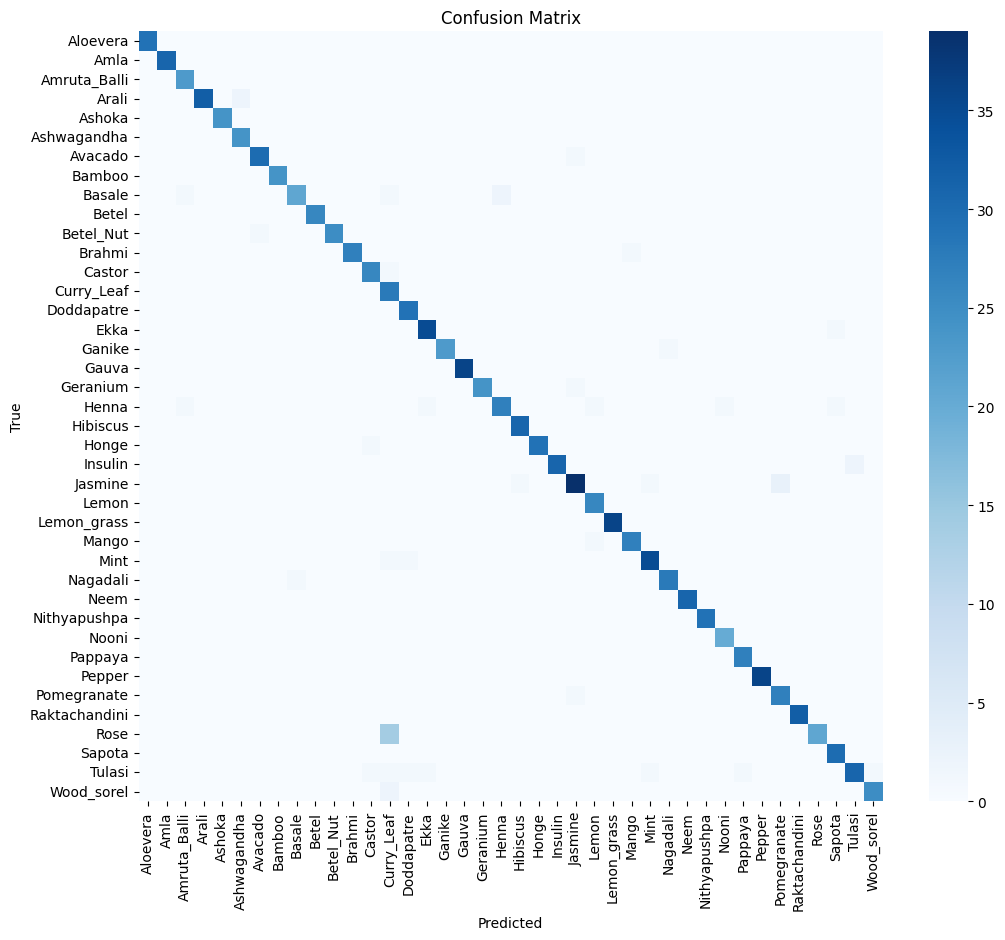

               precision    recall  f1-score   support

     Aloevera       1.00      1.00      1.00        29
         Amla       1.00      1.00      1.00        31
 Amruta_Balli       0.92      1.00      0.96        23
        Arali       1.00      0.94      0.97        34
       Ashoka       1.00      1.00      1.00        24
  Ashwagandha       0.92      1.00      0.96        24
      Avacado       0.97      0.97      0.97        31
       Bamboo       1.00      1.00      1.00        24
       Basale       0.95      0.84      0.89        25
        Betel       1.00      1.00      1.00        26
    Betel_Nut       1.00      0.96      0.98        26
       Brahmi       1.00      0.96      0.98        28
       Castor       0.93      0.96      0.95        27
   Curry_Leaf       0.58      1.00      0.74        28
   Doddapatre       0.94      1.00      0.97        29
         Ekka       0.95      0.97      0.96        36
       Ganike       1.00      0.96      0.98        24
        G

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))


In [ ]:
torch.save(model.state_dict(), "medicinal_leaf_model.pth")
